In [1]:
import os
import requests
import datetime as dt 
import pandas as pd
import geopandas
import shapely
from glob import glob
from os import path

/home/liangm/.conda/envs/ea_work/lib/python3.7/site-packages/geopandas/_compat.py:53: UserWarning: The installed version of PyGEOS is too old (0.6 installed, 0.8 required), and thus GeoPandas will not use PyGEOS.
  UserWarning,


In [2]:
doi ="10.3334/ORNLDAAC/2056"  
# CMR API base url
cmrurl='https://cmr.earthdata.nasa.gov/search/' 

doisearch = cmrurl + 'collections.json?doi=' + doi
concept_id = requests.get(doisearch).json()['feed']['entry'][0]['id']
print(concept_id)


C2237824918-ORNL_CLOUD


In [12]:
base_dir='EA_FR'

# Screach for L4a over a given AOI

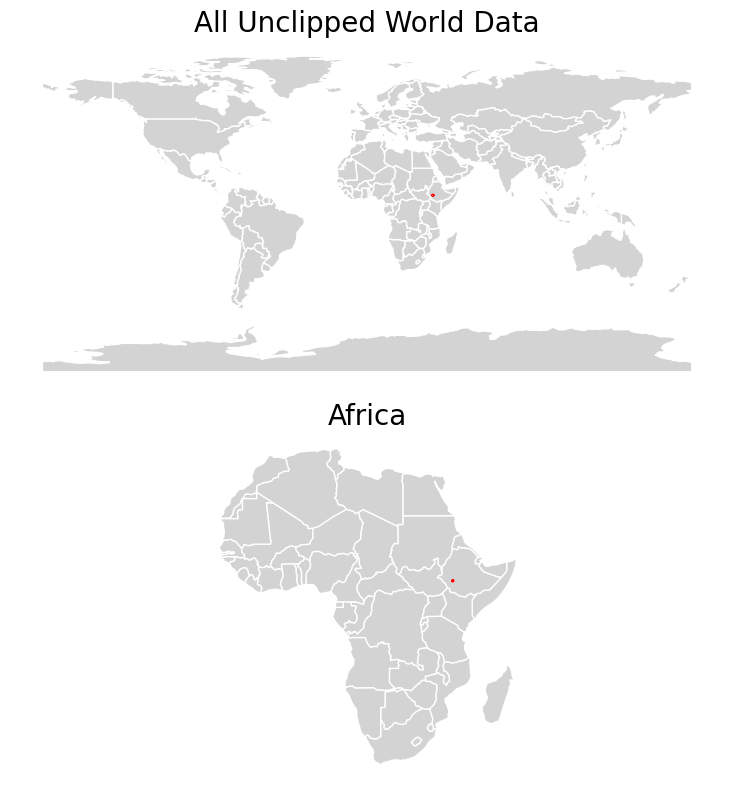

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import orient


world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# Create a subset of the world data that is just the targeted continent
Africa = world[world["continent"] == "Africa"]

amapa = amapa.to_crs(world.crs)                                                                                                               
                                                                                                                                                
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))                                                                                         
world.plot(ax=ax1, color="lightgray", edgecolor="white")                                                                                      
amapa.boundary.plot(ax=ax1, color="red", linewidth=2)                                                                                         
ax1.set_title("All Unclipped World Data", fontsize=20)                                                                                        

Africa.plot(ax=ax2, color="lightgray", edgecolor="white")                                                                                     
amapa.boundary.plot(ax=ax2, color="red", linewidth=2)  # also plot on Africa zoom                                                             
ax2.set_title("Africa", fontsize=20)                                                                                                          

ax1.set_axis_off()                                                                                                                            
ax2.set_axis_off()                                                                                                                            
plt.tight_layout()                                                                                                                            
plt.show()                                                                                                                                    



In [16]:
import requests
from shapely.geometry import MultiPolygon, Polygon
import pandas as pd

doi = '10.3334/ORNLDAAC/2056'# GEDI L4A DOI 

start_date= dt.datetime(2019, 4, 17)
# start_date= dt.datetime(2019, 1, 1)
end_date= dt.datetime(2024, 3, 17)
dt_format = '%Y-%m-%dT%H:%M:%SZ'
temporal_str = start_date.strftime(dt_format) + ',' + end_date.strftime(dt_format)



# CMR API base url
cmrurl='https://cmr.earthdata.nasa.gov/search/' 

doisearch = cmrurl + 'collections.json?doi=' + doi
concept_id = requests.get(doisearch).json()['feed']['entry'][0]['id']

geojson = {"shapefile": ("amapa.geojson", amapa.geometry.to_json(), "application/geo+json")}

page_num = 1
page_size = 2000 # CMR page size limit

granule_arr = []

concept_ids = 'C1908348134-LPDAAC_ECS'

while True:
    
     # defining parameters
    cmr_param = {
        "collection_concept_id": concept_id, 
        "page_size": page_size,
        "page_num": page_num,
         "temporal": temporal_str,
        "simplify-shapefile": 'true' # this is needed to bypass 5000 coordinates limit of CMR
    }
    
    granulesearch = cmrurl + 'granules.json'
    response = requests.post(granulesearch, data=cmr_param, files=geojson)
    print(response.json())
    granules = response.json()['feed']['entry']
       
    if granules:
        for g in granules:
            granule_url = ''
            granule_poly = ''
                       
            # read file size
            granule_size = float(g['granule_size'])
    
            # reading bounding geometries
            if 'polygons' in g:
                polygons= g['polygons']
                multipolygons = []
                for poly in polygons:
                    i=iter(poly[0].split (" "))
                    ltln = list(map(" ".join,zip(i,i)))
                    multipolygons.append(Polygon([[float(p.split(" ")[1]), float(p.split(" ")[0])] for p in ltln]))
                granule_poly = MultiPolygon(multipolygons)
            
            # Get URL to HDF5 files
            for links in g['links']:
                if 'title' in links and links['title'].startswith('Download') \
                and links['title'].endswith('.h5'):
                    granule_url = links['href']
            granule_arr.append([granule_url, granule_size, granule_poly])
               
        page_num += 1
    else: 
        break



{'feed': {'updated': '2026-03-31T05:15:50.540Z', 'id': 'https://cmr.earthdata.nasa.gov:443/search/granules.json', 'title': 'ECHO granule metadata', 'entry': [{'time_start': '2019-05-18T16:01:06.000Z', 'updated': '2025-09-25T19:27:06.000Z', 'dataset_id': 'GEDI L4A Footprint Level Aboveground Biomass Density, Version 2.1', 'data_center': 'ORNL_CLOUD', 'title': 'GEDI_L4A_AGB_Density_V2_1.GEDI04_A_2019138153812_O02435_02_T02427_02_002_02_V002.h5', 'coordinate_system': 'GEODETIC', 'day_night_flag': 'BOTH', 'time_end': '2019-05-18T16:24:16.000Z', 'id': 'G2613757995-ORNL_CLOUD', 'original_format': 'ECHO10', 'granule_size': '354.242421', 'browse_flag': False, 'polygons': [['0.066139 31.6114864 3.1326489 33.7727013 6.1925979 35.9499207 9.2406187 38.1541252 12.2725153 40.4023628 15.2802486 42.7075539 18.2550507 45.0843925 21.1954384 47.5559387 24.0863266 50.1326103 26.9248543 52.8399849 29.6938839 55.6944733 32.3858871 58.7231522 34.9870491 61.9509315 37.4811592 65.397377 39.850563 69.0900726 42

{'feed': {'updated': '2026-03-31T05:15:50.920Z', 'id': 'https://cmr.earthdata.nasa.gov:443/search/granules.json', 'title': 'ECHO granule metadata', 'entry': []}}


In [17]:
# adding bound as the last row into the dataframe
# we will use this later in the plot
granule_arr.append(['amapa', 0, amapa.geometry.item() ]) 

# creating a pandas dataframe
l4adf = pd.DataFrame(granule_arr, columns=["granule_url", "granule_size", "granule_poly"])

# Drop granules with empty geometry
l4adf = l4adf[l4adf['granule_poly'] != '']

print ("Total granules found: ", len(l4adf.index)-1 )
print ("Total file size (MB): ", l4adf['granule_size'].sum())

Total granules found:  35
Total file size (MB):  11580.144623999999


In [18]:
l4adf.tail()

,granule_url,granule_size,granule_poly
31,https://data.ornldaac.earthdata.nasa.gov/prote...,302.061934,"(POLYGON ((-43.600399 51.7508316, -37.6152687 ..."
32,https://data.ornldaac.earthdata.nasa.gov/prote...,307.033061,"(POLYGON ((-42.9596977 51.7563515, -36.9789505..."
33,https://data.ornldaac.earthdata.nasa.gov/prote...,363.866811,"(POLYGON ((31.1709728 -0.266194, 33.3257065 2...."
34,https://data.ornldaac.earthdata.nasa.gov/prote...,318.542295,"(POLYGON ((-43.0676003 51.7560081, -37.0795097..."
35,amapa,0.000000,"POLYGON ((36.4927375 7.2502184, 36.4711082 7.1..."


### Download the granules to a text file     

In [19]:
# drop duplicate URLs if any
l4a_granules = l4adf[:-1].drop_duplicates(subset=['granule_url'])

l4a_granules.to_csv('AOI_l4a_granules_2019-2023.txt', columns = ['granule_url'], index=False, header = False)  #kibale linkes

print( len(l4adf.index)-1 )
print(len(l4a_granules))

35
35
